# Inference — Confident-non-match (gate) model on a labeled pairs test set

Load a **saved `.pkl`** (you choose which) from the *non-match-gate* family and score it on a
labeled **pairs** dataset — by default `data/synthetic_data/synthetic_test_v3.csv`
(`label`: `1` = match, `0` = not-match). **No training happens here.**

**What this model does.** The gate outputs `P(plausible) = P(match ∪ ambiguous) = predict_proba[:, 1]`.
*High* → keep the pair (plausible); *low* → **confident non-match**, drop it. Its job is to discard
confident non-matches while keeping everything worth a closer look.

**No ambiguous column.** The synthetic labels are only match / not-match, so *plausible* collapses to
*match*: a true match (`label=1`) should score **high** `P(plausible)` (kept) and a true non-match
(`label=0`) should score **low** (correctly gated out). We therefore evaluate `P(plausible)` as a
match-vs-not-match score, where **passing the gate = predicting match**.

**Scope.** Uses the production `V3FeatureBuilder` (the 12 v3 features), matching `nonmatch_gate_v1`.

## 1. Configuration — pick the model + gate threshold

In [6]:
# --- Choose the model artifact (.pkl). Leave as None to auto-pick the newest under models/. ---
MODEL_PATH = None

# How to read predict_proba(X)[:, 1] for this artifact:
#   'auto' / 'gate' : raw non-match-gate LGBM -> col 1 = P(plausible) = P(match ∪ ambiguous)
MODEL_KIND = 'auto'

# Keep the pair (predict plausible/match) when P(plausible) >= THRESHOLD; else confident non-match.
# 0.30 is the nonmatch_gate notebook's operating point (favors recall on plausible so real
# matches are not dropped). The gate sweep (§6) shows the whole trade-off.
THRESHOLD = 0.30

SYNTHETIC_REL = 'synthetic_data/synthetic_test_v3.csv'

In [7]:
import sys, re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve,
)


def _find_service_root(start: Path) -> Path:
    for d in [start, *start.parents]:
        if (d / 'data').is_dir() and (d / 'src').is_dir():
            return d
    raise FileNotFoundError('could not locate empi-service/ (no ancestor has data/ + src/)')


SERVICE_ROOT = _find_service_root(Path.cwd())
if str(SERVICE_ROOT) not in sys.path:
    sys.path.insert(0, str(SERVICE_ROOT))
DATA_DIR = SERVICE_ROOT / 'data'

# Production feature builder (+ adapter class so joblib can unpickle either artifact kind).
from src.models.ml_matcher.lightgbm_v3 import V3FeatureBuilder, MatchProbabilityAdapter, FEATURE_COLS
print('service root :', SERVICE_ROOT)
print('features     :', FEATURE_COLS)

service root : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service
features     : ['sound_first', 'sound_last', 'cmp_street_num', 'sim_jw_first', 'sim_jw_last', 'sim_jw_middle', 'sim_lev_email', 'sim_lev_address1', 'addr_token_jaccard', 'ssn_digit_frac', 'sim_dob', 'sim_phones']


In [8]:
# Prefer this notebook's own model family (models/nonmatch_gate/), then fall back to all of models/.
PREFERRED_SUBDIR = 'nonmatch_gate'   # non-match-gate artifacts live here


def _looks_corrupt(p: Path) -> bool:
    """True if the file is empty or begins with NUL bytes — not a valid pickle stream.
    A zero-filled/truncated copy is the usual cause of joblib's cryptic `KeyError: 0`."""
    try:
        with open(p, 'rb') as fh:
            head = fh.read(16)
    except OSError:
        return True
    return len(head) == 0 or set(head) == {0}


available = sorted((SERVICE_ROOT / 'models').rglob('*.pkl'))
print('available .pkl artifacts under models/  (x = corrupt/empty):')
for p in available:
    flag = 'x' if _looks_corrupt(p) else 'ok'
    print(f'  [{flag}] {p.relative_to(SERVICE_ROOT)}  ({p.stat().st_size} bytes)')
if not available:
    print('  (none — export a gate model first, or set MODEL_PATH to a .pkl elsewhere)')

if MODEL_PATH is None:
    preferred = [p for p in available if p.parent.name == PREFERRED_SUBDIR]
    pool = [p for p in (preferred or available) if not _looks_corrupt(p)]
    if not pool:
        raise FileNotFoundError(
            f'no usable .pkl found (looked in models/{PREFERRED_SUBDIR} first, then all of models/). '
            'Files are missing or corrupt (all-zero bytes) — re-copy a valid model artifact, or set '
            'MODEL_PATH explicitly.')
    where = f'models/{PREFERRED_SUBDIR}' if preferred else 'models/'
    MODEL_PATH = max(pool, key=lambda p: p.stat().st_mtime)
    print(f'\nMODEL_PATH not set -> auto-picked newest valid in {where}: '
          f'{MODEL_PATH.relative_to(SERVICE_ROOT)}')

MODEL_PATH = Path(MODEL_PATH)
assert MODEL_PATH.exists(), f'MODEL_PATH does not exist: {MODEL_PATH}'
if _looks_corrupt(MODEL_PATH):
    raise ValueError(
        f'{MODEL_PATH} is empty or all-zero bytes — the model file is corrupt, not a valid pickle. '
        'Re-copy/regenerate it (a truncated or zero-filled transfer is the usual cause).')
print('using model :', MODEL_PATH)

available .pkl artifacts under models/  (x = corrupt/empty):
  [ok] models\ml\ml_model_20260719T141543Z.pkl  (733302 bytes)
  [ok] models\ml\ml_model_20260721T163138Z.pkl  (848294 bytes)
  [ok] models\nonmatch_gate\nonmatch_gate_20260721T160717Z.pkl  (319556 bytes)

MODEL_PATH not set -> auto-picked newest valid in models/nonmatch_gate: models\nonmatch_gate\nonmatch_gate_20260721T160717Z.pkl
using model : c:\Users\MiguelGarcia\Documents\UofC-EMPI\empi-service\models\nonmatch_gate\nonmatch_gate_20260721T160717Z.pkl


## 2. Load the test set and reshape to (records + candidate pairs)
The CSV stores each pair inline with `_l`/`_r` suffixes. `V3FeatureBuilder` expects a **records**
table (one row per PATID) plus a **candidate-pairs** table (`PATID_A`, `PATID_B`), so we split the
two sides back out. Phones are space-separated here, so we parse them into real sets.

In [9]:
SYNTHETIC_PATH = DATA_DIR / SYNTHETIC_REL
raw = pd.read_csv(SYNTHETIC_PATH, dtype=str)   # dtype=str preserves leading zeros (SSN/ZIP/PATID)
raw['label'] = raw['label'].astype(int)
print('test pairs:', len(raw))
print('label distribution (1=match, 0=not-match):')
print(raw['label'].value_counts())

BASE_COLS = ['FirstNM_clean', 'LastNM_clean', 'MiddleNM_clean', 'BirthDT_clean',
             'SSN_clean', 'Email_clean', 'AddressLine1_clean', 'Phones_set']


def _phoneset(s):
    """Space- or comma-separated phone string -> set of numbers (also handles the legacy {..} form)."""
    if not isinstance(s, str):
        return set()
    s = s.strip().strip('{}[]').replace("'", '').replace('"', '')
    return {p for p in re.split(r'[,\s]+', s) if p}


def _side_records(suffix, patid_col):
    out = pd.DataFrame({'PATID': raw[patid_col].astype(str)})
    for c in BASE_COLS:
        col = f'{c}_{suffix}'
        out[c] = raw[col] if col in raw.columns else np.nan
    return out


recs = pd.concat([_side_records('l', 'PATID_A'), _side_records('r', 'PATID_B')], ignore_index=True)
recs = recs.drop_duplicates('PATID', keep='first').reset_index(drop=True)
recs['Phones_set'] = recs['Phones_set'].map(_phoneset)

candidate_pairs = raw[['PATID_A', 'PATID_B']].astype(str).copy()
print('\nunique records:', len(recs), '| candidate pairs:', len(candidate_pairs))

test pairs: 10000
label distribution (1=match, 0=not-match):
label
0    8000
1    2000
Name: count, dtype: int64

unique records: 20000 | candidate pairs: 10000


## 3. Build features (production `V3FeatureBuilder`)

In [10]:
feat = V3FeatureBuilder().build_features(candidate_pairs, recs)
X = feat[FEATURE_COLS]
print('feature matrix:', X.shape)
print('NaN fraction per feature:')
display(X.isna().mean().round(3).to_frame('pct_missing'))
X.head()

feature matrix: (10000, 12)
NaN fraction per feature:


,pct_missing
sound_first,0.000
sound_last,0.000
cmp_street_num,0.000
sim_jw_first,0.000
sim_jw_last,0.000
sim_jw_middle,0.931
sim_lev_email,0.864
sim_lev_address1,0.052
addr_token_jaccard,0.052
ssn_digit_frac,0.956


,sound_first,sound_last,cmp_street_num,sim_jw_first,sim_jw_last,sim_jw_middle,sim_lev_email,sim_lev_address1,addr_token_jaccard,ssn_digit_frac,sim_dob,sim_phones
0,different,same,missing,0.511905,1.000000,NaN,NaN,NaN,NaN,NaN,1.000,0.600000
1,different,different,different,0.527778,0.467320,NaN,NaN,0.2,0.0,NaN,1.000,0.677778
2,different,different,same,0.533333,0.466667,NaN,NaN,1.0,1.0,NaN,0.375,0.622222
3,different,different,same,0.502646,0.000000,NaN,NaN,1.0,1.0,NaN,1.000,0.516667
4,different,same,same,0.722222,1.000000,NaN,NaN,1.0,1.0,NaN,0.750,0.566667


## 4. Load the model and score
`p_plausible = P(match ∪ ambiguous) = predict_proba[:, 1]`; passing the gate (`>= THRESHOLD`) is the
predicted-match decision.

In [11]:
loaded = joblib.load(MODEL_PATH)
if isinstance(loaded, MatchProbabilityAdapter):
    print('WARNING: this looks like a confident-MATCH artifact (MatchProbabilityAdapter), not a\n'
          '         non-match gate. Its column 1 is P(confident match), not P(plausible).\n'
          '         Use inference_confident_match.ipynb instead, or interpret results accordingly.')

kind = MODEL_KIND if MODEL_KIND != 'auto' else 'gate'
assert kind == 'gate', f'this notebook expects a gate model; got MODEL_KIND={kind}'

p_plausible = np.asarray(loaded.predict_proba(X))[:, 1]   # P(match ∪ ambiguous)

y_true = raw['label'].to_numpy()                          # 1 = match(=plausible), 0 = not-match
y_pred = (p_plausible >= THRESHOLD).astype(int)           # 1 = passes gate (predict match)
print(f"scored {len(p_plausible)} pairs | P(plausible): min={p_plausible.min():.3f} "
      f"mean={p_plausible.mean():.3f} max={p_plausible.max():.3f}")

scored 10000 pairs | P(plausible): min=0.000 mean=0.254 max=1.000


## 5. Evaluation — classification report + confusion matrix
Positive class = **plausible (match)** = passes the gate. Negative = **confident non-match** = dropped.

Model : nonmatch_gate_20260721T160717Z.pkl   (kind=gate)
Gate threshold (keep if P(plausible) >= t): 0.3

                         precision    recall  f1-score   support

confident non-match (0)      0.995     0.894     0.942      8000
  plausible / match (1)      0.699     0.983     0.817      2000

               accuracy                          0.912     10000
              macro avg      0.847     0.938     0.879     10000
           weighted avg      0.936     0.912     0.917     10000

ROC AUC : 0.9941
PR  AUC : 0.9815


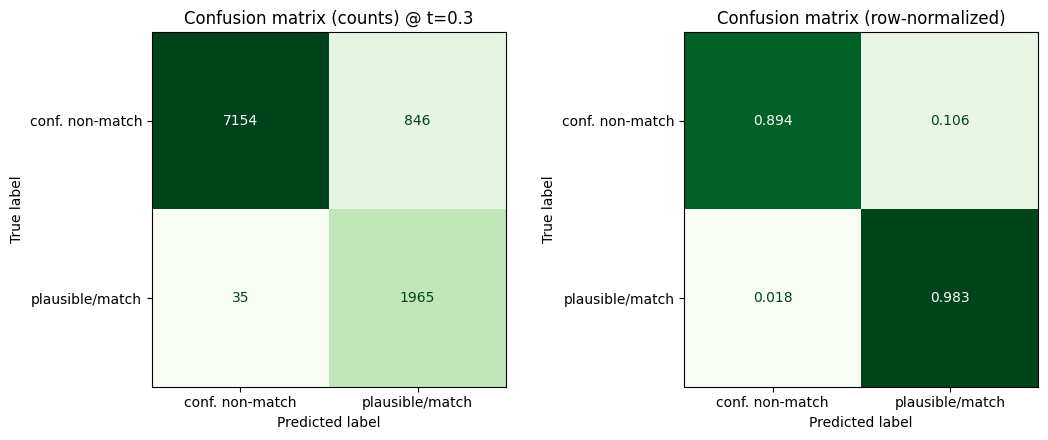

In [12]:
print(f'Model : {MODEL_PATH.name}   (kind={kind})')
print(f'Gate threshold (keep if P(plausible) >= t): {THRESHOLD}\n')
print(classification_report(y_true, y_pred,
                            target_names=['confident non-match (0)', 'plausible / match (1)'], digits=3))
print(f'ROC AUC : {roc_auc_score(y_true, p_plausible):.4f}')
print(f'PR  AUC : {average_precision_score(y_true, p_plausible):.4f}')

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
labels = ['conf. non-match', 'plausible/match']
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred), display_labels=labels).plot(
    ax=ax[0], colorbar=False, cmap='Greens')
ax[0].set_title(f'Confusion matrix (counts) @ t={THRESHOLD}')
ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred, normalize='true'), display_labels=labels).plot(
    ax=ax[1], colorbar=False, cmap='Greens', values_format='.3f')
ax[1].set_title('Confusion matrix (row-normalized)')
plt.tight_layout(); plt.show()

## 6. Gate operating points + ROC / PR curves
For a gate the key numbers are: how much of the pool is **kept**, what fraction of true matches is
**wrongly dropped** (miss rate), and how many true non-matches are **correctly gated out**.

,threshold,kept_frac,match_recall,match_miss_rate,nonmatch_dropped_frac,kept_precision,accuracy
0,0.1,0.3532,0.9960,0.0040,0.8075,0.5640,0.8452
1,0.2,0.3304,0.9890,0.0110,0.8342,0.5987,0.8652
2,0.3,0.2811,0.9825,0.0175,0.8942,0.6990,0.9119
3,0.4,0.2559,0.9725,0.0275,0.9232,0.7601,0.9331
4,0.5,0.2295,0.9660,0.0340,0.9546,0.8418,0.9569
5,0.6,0.2055,0.9510,0.0490,0.9809,0.9255,0.9749
6,0.7,0.1994,0.9425,0.0575,0.9864,0.9453,0.9776
7,0.8,0.1910,0.9255,0.0745,0.9926,0.9691,0.9792
8,0.9,0.1866,0.9075,0.0925,0.9936,0.9727,0.9764


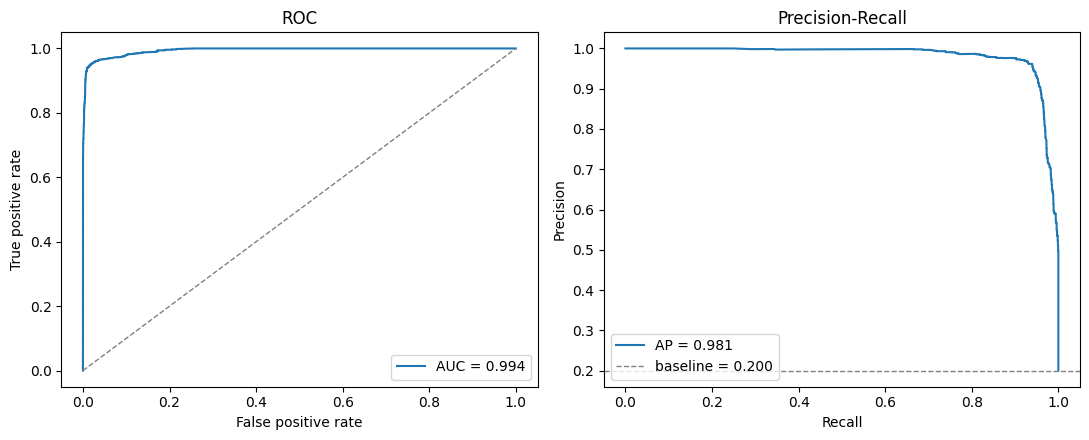

In [13]:
P = int((y_true == 1).sum())
N = int((y_true == 0).sum())
rows = []
for thr in np.round(np.arange(0.1, 0.95, 0.1), 2):
    keep = p_plausible >= thr
    tp = int(((y_true == 1) & keep).sum())
    fn = int(((y_true == 1) & ~keep).sum())       # true match wrongly dropped
    tn = int(((y_true == 0) & ~keep).sum())       # true non-match correctly gated out
    fp = int(((y_true == 0) & keep).sum())
    rows.append({
        'threshold': thr,
        'kept_frac': keep.mean(),
        'match_recall': tp / P if P else np.nan,
        'match_miss_rate': fn / P if P else np.nan,
        'nonmatch_dropped_frac': tn / N if N else np.nan,
        'kept_precision': tp / (tp + fp) if (tp + fp) else np.nan,
        'accuracy': (keep.astype(int) == y_true).mean(),
    })
display(pd.DataFrame(rows).round(4))

fpr, tpr, _ = roc_curve(y_true, p_plausible)
prec, rec, _ = precision_recall_curve(y_true, p_plausible)
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_true, p_plausible):.3f}')
ax[0].plot([0, 1], [0, 1], '--', color='grey', lw=1)
ax[0].set(xlabel='False positive rate', ylabel='True positive rate', title='ROC'); ax[0].legend(loc='lower right')
ax[1].plot(rec, prec, label=f'AP = {average_precision_score(y_true, p_plausible):.3f}')
ax[1].axhline(y_true.mean(), ls='--', color='grey', lw=1, label=f'baseline = {y_true.mean():.3f}')
ax[1].set(xlabel='Recall', ylabel='Precision', title='Precision-Recall'); ax[1].legend(loc='lower left')
plt.tight_layout(); plt.show()

## 7. Breakdown by `case_type`
`M-*` = match scenarios, `NM-*` = non-match scenarios. Mean `P(plausible)` and gate accuracy per
family, plus the hardest individual case types.

In [14]:
ev = pd.DataFrame({
    'case_type': raw.get('case_type', pd.Series(['?'] * len(raw))),
    'label': y_true, 'p_plausible': p_plausible, 'pred': y_pred,
})
ev['family'] = ev['case_type'].astype(str).str.split('-').str[0]      # 'M' or 'NM'
ev['correct'] = (ev['pred'] == ev['label'])

print('By family:')
display(ev.groupby('family').agg(n=('label', 'size'), mean_p_plausible=('p_plausible', 'mean'),
                                 accuracy=('correct', 'mean')).round(4))

print('Hardest 12 case types (lowest accuracy, min 10 pairs):')
g = ev.groupby('case_type').agg(n=('label', 'size'), label=('label', 'first'),
                                mean_p_plausible=('p_plausible', 'mean'), accuracy=('correct', 'mean'))
display(g[g['n'] >= 10].sort_values('accuracy').head(12).round(4))

By family:


,n,mean_p_plausible,accuracy
family,,,
M,1960,0.9542,0.9821
NM,8000,0.0782,0.8942
POL,40,0.9997,1.0000


Hardest 12 case types (lowest accuracy, min 10 pairs):


,n,label,mean_p_plausible,accuracy
case_type,,,,
NM-HARD-DOB+LAST4+PHONE,15,0,0.5286,0.0000
NM-HARD-DOB+PHONE,225,0,0.5154,0.0356
NM-HARD-ADDR+DOB+PHONE,121,0,0.4982,0.0579
NM-HARD-DOB+LASTNAME+PHONE,124,0,0.4014,0.1452
M-NAME-02,44,1,0.2507,0.3182
NM-HH-JR-SR,94,0,0.3791,0.4362
NM-HARD-ADDR+DOB+LASTNAME,133,0,0.3973,0.4436
NM-HH-TWIN,94,0,0.3837,0.5532
NM-HARD-ADDR+FIRSTNAME+LASTNAME+PHONE,122,0,0.2624,0.6885
